## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

---

In [1]:
import pandas as pd

df = pd.read_csv("../datasets/amz_uk_price_prediction_dataset.csv")

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\M. Grillo\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3



### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*



In [3]:

ct = pd.crosstab(df['category'], df['isBestSeller'])


In [4]:
ct = pd.crosstab(df['category'], df['isBestSeller'])
ct[True] / (ct[True] + ct[False]) 

ct['bestsellerprop'] = (ct[True] / (ct[True] + ct[False]) )
ctsorted_by = ct.sort_values(by='bestsellerprop', ascending=False).head(19)
#print(ctsorted_by)
#ctsorted_by.index

ctsorted_by


isBestSeller,False,True,bestsellerprop
category,,,
Grocery,9008,556,0.058135
Smart Home Security & Lighting,98,6,0.057692
Health & Personal Care,9017,552,0.057686
Mobile Phone Accessories,248,11,0.042471
Power & Hand Tools,8353,306,0.035339
"Billiard, Snooker & Pool",241,8,0.032129
Pet Supplies,9152,285,0.030200
Home Brewing & Wine Making,239,7,0.028455
Wind Instruments,243,7,0.028000


In [5]:
#ct.proportion_Bsellers = (ct[True])/(ct[True] + ct[False])
#ct.proportion_Bsellers.head(20)
ctsorted_by.index

Index(['Grocery', 'Smart Home Security & Lighting', 'Health & Personal Care',
       'Mobile Phone Accessories', 'Power & Hand Tools',
       'Billiard, Snooker & Pool', 'Pet Supplies',
       'Home Brewing & Wine Making', 'Wind Instruments', 'Mirrors',
       'Professional Medical Supplies', 'PC & Video Games', 'Bakeware',
       'Material Handling Products', 'Bedding Accessories', 'Tableware',
       'Arts & Crafts', 'Baby', 'Lighting'],
      dtype='object', name='category')

answer: these categories (only) hold best chances of being a bestseller:
Index(['Grocery', 'Smart Home Security & Lighting', 'Health & Personal Care',
       'Mobile Phone Accessories', 'Power & Hand Tools',
       'Billiard, Snooker & Pool', 'Pet Supplies',
       'Home Brewing & Wine Making', 'Wind Instruments', 'Mirrors',
       'Professional Medical Supplies', 'PC & Video Games', 'Bakeware',
       'Material Handling Products', 'Bedding Accessories', 'Tableware',
       'Arts & Crafts', 'Baby', 'Lighting'],

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [6]:
from scipy.stats import chi2_contingency

_, chi2_pvalue, _, _  = chi2_contingency(ct)

chi2_pvalue


np.float64(0.0)

chi2_pvalue is 0 --> strong evidence that there is a strong dependence

In [7]:
ct.corr()

isBestSeller,False,True,bestsellerprop
isBestSeller,,,
False,1.000000,0.300777,-0.055563
True,0.300777,1.000000,0.538995
bestsellerprop,-0.055563,0.538995,1.000000


a correlation of 0.3 is not that strong.

In [9]:
from scipy.stats import contingency

chi2_properties = contingency.association(ct, method='cramer')
print(f"Cramer's V (Strength of Association): {chi2_properties}")

ValueError: `observed` must be an integer array.

0.12 not convincing - weak!




3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


<Axes: xlabel='category'>

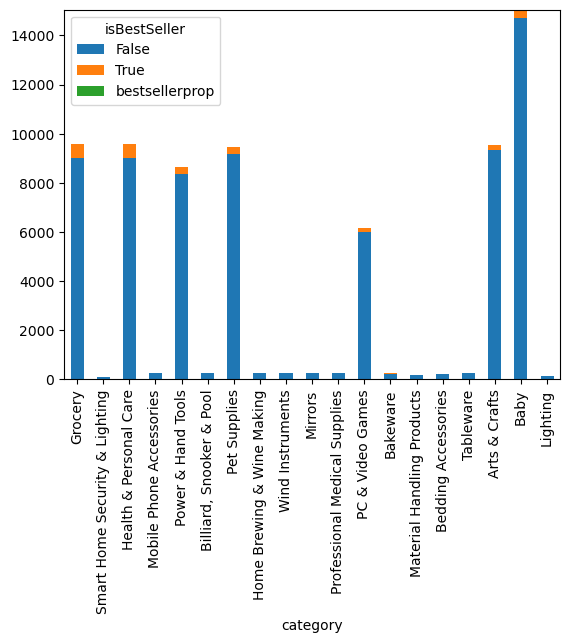

In [66]:
ctsorted_by.plot(kind='bar', stacked=True)

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [71]:
#df.info()

In [70]:
# 1. Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define your bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the DataFrame
filtered_df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
df= filtered_df

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.


<Axes: xlabel='price', ylabel='category'>

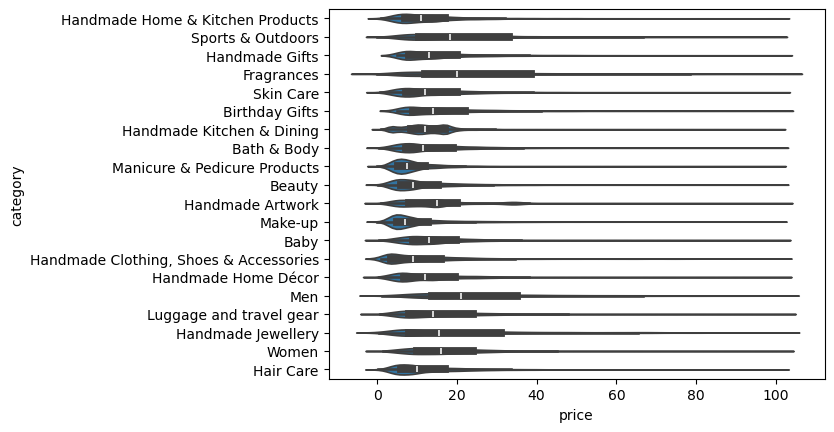

In [88]:
hitlist = (df['category'].value_counts().head(20).index.to_list())
hitlistdf = df[df['category'].isin(hitlist)]

import seaborn as sns
sns.violinplot(data=hitlistdf, x="price", y="category")

In [10]:
meanm = df.groupby('category')['price'].mean()
meanm.sort_values(ascending=False).head(1)

category
Laptops    1087.987827
Name: price, dtype: float64

highest median price is in 

category
Motherboards    68.772432
Name: price, dtype: float64

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).


In [11]:
hitlist10 = (df['category'].value_counts().head(10).index.to_list())
hitlist10df = df[df['category'].isin(hitlist10)]
#avgm = hitlist10df.groupby('category')['price'].mean()
sns.barplot(data=hitlist10df,x='category', y='price')
import matplotlib.pyplot as plt
plt.xticks(rotation=45, ha='right')
plt.show()


NameError: name 'sns' is not defined

    - Which product category commands the highest average price? Don't filter here by top categories.

In [102]:
df.groupby('category')['price'].mean().sort_values(ascending=False).head(1)


category
Motherboards    68.772432
Name: price, dtype: float64

again: it is Motherboards
category
Motherboards    68.772432

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2115963 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 147.3+ MB


<class 'pandas.core.frame.DataFrame'>
Index: 862465 entries, 82163 to 2437154
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   uid                862465 non-null  int64  
 1   asin               862465 non-null  object 
 2   title              862465 non-null  object 
 3   stars              862465 non-null  float64
 4   reviews            862465 non-null  int64  
 5   price              862465 non-null  float64
 6   isBestSeller       862465 non-null  bool   
 7   boughtInLastMonth  862465 non-null  int64  
 8   category           862465 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 60.0+ MB


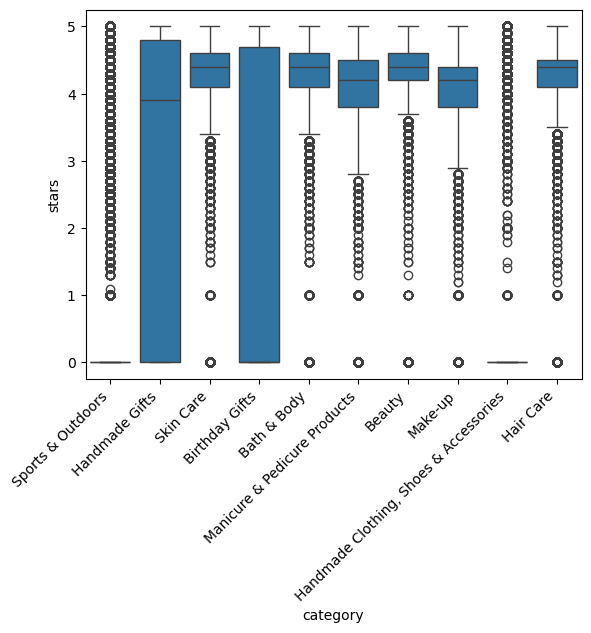

In [119]:
hitlist10 = (df['category'].value_counts().head(10).index.to_list())
hitlist10df = df[df['category'].isin(hitlist10)]
hitlist10df.info()
sns.boxplot(data=hitlist10df,x='category',y='stars')
import matplotlib.pyplot as plt
plt.xticks(rotation=45, ha='right')
plt.show()

    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [12]:
df.groupby('category')['stars'].mean().sort_values(ascending=False).head(1)

category
Luxury Food & Drink    4.54757
Name: stars, dtype: float64

here it's Luxury Food & Drink  in mean  4.54414 stars


### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.

In [ ]:
crt = pd.crosstab(df['price'], df['stars'])
#crt.corr()
from scipy.stats import contingency
contingency.association(crt)
#crt


round(float(df["stars"].corr(df["price"], method="spearman")), 2)


-0.13

In [14]:
round(float(df["stars"].corr(df["price"], method="pearson")), 2)

-0.12


    - Is there a significant correlation between product price and its rating?
    no

poor correlation

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

<Axes: xlabel='stars', ylabel='price'>

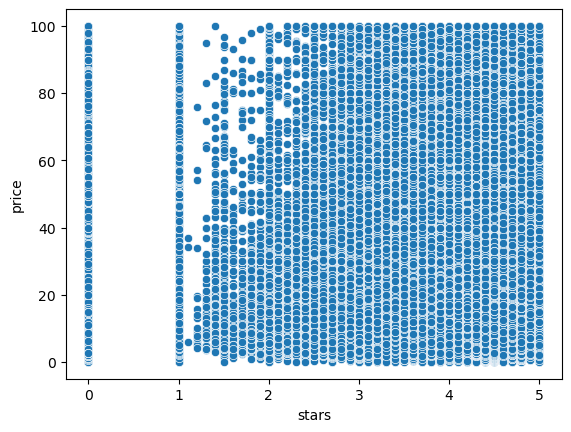

In [126]:
sns.scatterplot(df, x='stars', y='price')

there are no stars between 0 and 1.

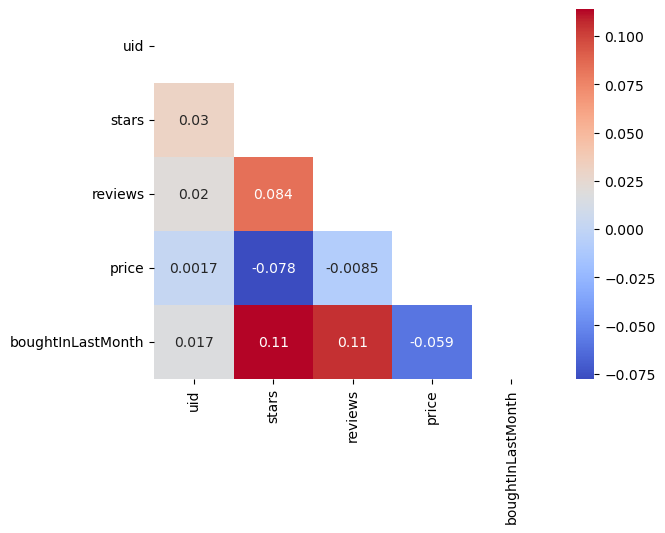

In [129]:
num = df.select_dtypes(include="number")
numc = num.corr()
import numpy as np
mask=np.triu(np.ones_like(numc,dtype=bool))

sns.heatmap(numc, mask=mask, annot=True, cmap="coolwarm")
plt.show()


althougj written in red. corr is low

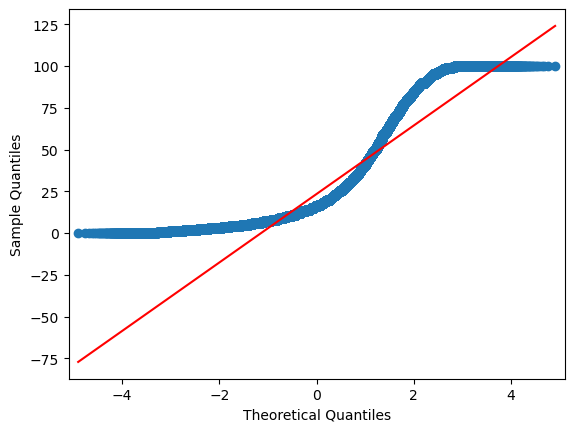

In [131]:
import statsmodels.api as sm
sm.qqplot(df['price'], line='s');

red line would be a normal distribution.
but small prices are much more often.